# 03 — Pembersihan dan Persiapan Dataset Citra Awan

Notebook ini digunakan untuk membersihkan dan menyiapkan Ground-based Cloud Dataset (GCD) sebelum masuk ke tahap preprocessing dan pelatihan model.

Dataset dibaca dari:

dataset/raw/GCD/GCD/
├── train/
└── test/

Hasil pembersihan disimpan pada:

dataset/source/
├── train/
├── val/
└── test/

Tujuan notebook:

1. Memeriksa keterbacaan setiap file citra.
2. Menemukan citra rusak atau tidak valid.
3. Memeriksa ukuran dan format citra.
4. Mendeteksi file yang benar-benar identik menggunakan SHA-256.
5. Mencegah kebocoran data antara train, validation, dan test.
6. Membagi training original menjadi train dan validation secara stratified.
7. Menyalin test original hanya ke source/test.
8. Membuat inventory, audit pembersihan, manifest split, dan ringkasan hasil.

Dataset pada folder raw tidak akan dimodifikasi, dihapus, dipindahkan, atau diganti nama.

In [36]:
from pathlib import Path
from hashlib import sha256
from datetime import datetime

import json
import math
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image, UnidentifiedImageError

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, total=None, desc=None):
        if desc:
            print(desc)
        return iterable

print("Seluruh library berhasil diimpor.")

Seluruh library berhasil diimpor.


## Menentukan Lokasi Project

Notebook dijalankan langsung melalui VS Code/Jupyter. Oleh karena itu, lokasi project ditentukan secara dinamis tanpa menggunakan path Docker `/app`.

In [37]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET_DIR = PROJECT_DIR / "dataset"

RAW_DIR = DATASET_DIR / "raw"
RAW_GCD_DIR = RAW_DIR / "GCD" / "GCD"
RAW_TRAIN_DIR = RAW_GCD_DIR / "train"
RAW_TEST_DIR = RAW_GCD_DIR / "test"

SOURCE_DIR = DATASET_DIR / "source"
SOURCE_TRAIN_DIR = SOURCE_DIR / "train"
SOURCE_VAL_DIR = SOURCE_DIR / "val"
SOURCE_TEST_DIR = SOURCE_DIR / "test"

PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

path_table = pd.DataFrame({
    "Nama": [
        "Project",
        "Raw train",
        "Raw test",
        "Source train",
        "Source validation",
        "Source test",
        "Processed",
    ],
    "Path": [
        PROJECT_DIR,
        RAW_TRAIN_DIR,
        RAW_TEST_DIR,
        SOURCE_TRAIN_DIR,
        SOURCE_VAL_DIR,
        SOURCE_TEST_DIR,
        PROCESSED_DIR,
    ],
    "Ada": [
        PROJECT_DIR.exists(),
        RAW_TRAIN_DIR.exists(),
        RAW_TEST_DIR.exists(),
        SOURCE_TRAIN_DIR.exists(),
        SOURCE_VAL_DIR.exists(),
        SOURCE_TEST_DIR.exists(),
        PROCESSED_DIR.exists(),
    ],
})

display(path_table)

,Nama,Path,Ada
0,Project,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,Raw train,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\train,True
2,Raw test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test,True
3,Source train,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\train,True
4,Source validation,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\val,True
5,Source test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test,True
6,Processed,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True


## Konfigurasi Pembersihan

Validation diambil dari training original dengan pembagian stratified sebesar 20%.

RESET_SOURCE bernilai True berarti folder source/train, source/val, dan source/test akan dibangun ulang. Operasi ini tidak menyentuh dataset/raw.

In [38]:
RANDOM_STATE = 42
VAL_RATIO = 0.20

MIN_WIDTH = 32
MIN_HEIGHT = 32

RESET_SOURCE = True

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

assert 0 < VAL_RATIO < 1, (
    "VAL_RATIO harus lebih besar dari 0 dan lebih kecil dari 1."
)

assert MIN_WIDTH > 0
assert MIN_HEIGHT > 0

print(f"Rasio validation : {VAL_RATIO:.0%}")
print(f"Random state     : {RANDOM_STATE}")
print(f"Ukuran minimum   : {MIN_WIDTH} × {MIN_HEIGHT} piksel")
print(f"Reset source     : {RESET_SOURCE}")

Rasio validation : 20%
Random state     : 42
Ukuran minimum   : 32 × 32 piksel
Reset source     : True


In [39]:
def is_inside(child: Path, parent: Path) -> bool:
    """
    Memeriksa apakah suatu path berada di dalam path induk.

    Fungsi ini digunakan sebagai pengaman agar operasi file
    tidak mengarah ke lokasi di luar dataset/source.
    """
    child_resolved = child.resolve()
    parent_resolved = parent.resolve()

    common_path = os.path.commonpath([
        str(child_resolved),
        str(parent_resolved),
    ])

    return common_path == str(parent_resolved)


required_raw_dirs = [
    RAW_TRAIN_DIR,
    RAW_TEST_DIR,
]

missing_raw_dirs = [
    path
    for path in required_raw_dirs
    if not path.is_dir()
]

if missing_raw_dirs:
    missing_text = "\n".join(
        f"- {path}"
        for path in missing_raw_dirs
    )

    raise FileNotFoundError(
        "Folder dataset raw belum lengkap:\n"
        f"{missing_text}\n\n"
        "Pastikan GCD.zip sudah diekstrak ke:\n"
        "dataset/raw/GCD/GCD/"
    )


expected_source_dir = (DATASET_DIR / "source").resolve()

assert SOURCE_DIR.resolve() == expected_source_dir, (
    "Lokasi SOURCE_DIR tidak sesuai dengan dataset/source."
)

assert not is_inside(RAW_GCD_DIR, SOURCE_DIR), (
    "Folder raw tidak boleh berada di dalam source."
)

assert not is_inside(SOURCE_DIR, RAW_GCD_DIR), (
    "Folder source tidak boleh berada di dalam raw."
)


raw_train_files = [
    path
    for path in RAW_TRAIN_DIR.rglob("*")
    if path.is_file()
]

raw_test_files = [
    path
    for path in RAW_TEST_DIR.rglob("*")
    if path.is_file()
]

if not raw_train_files:
    raise RuntimeError(
        f"Tidak ditemukan file pada {RAW_TRAIN_DIR}"
    )

if not raw_test_files:
    raise RuntimeError(
        f"Tidak ditemukan file pada {RAW_TEST_DIR}"
    )


SOURCE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Jumlah file raw train : {len(raw_train_files):,}")
print(f"Jumlah file raw test  : {len(raw_test_files):,}")
print("Pemeriksaan struktur folder: LULUS")

Jumlah file raw train : 10,000
Jumlah file raw test  : 9,000
Pemeriksaan struktur folder: LULUS


In [40]:
def build_raw_snapshot(root: Path) -> pd.DataFrame:
    """
    Membuat snapshot seluruh file raw berdasarkan:
    - path relatif;
    - ukuran file;
    - waktu modifikasi.
    """
    records = []

    file_paths = sorted(
        path
        for path in root.rglob("*")
        if path.is_file()
    )

    for path in file_paths:
        stat = path.stat()

        records.append({
            "relative_path": path.relative_to(root).as_posix(),
            "size_bytes": stat.st_size,
            "mtime_ns": stat.st_mtime_ns,
        })

    snapshot_df = pd.DataFrame(records)

    if not snapshot_df.empty:
        snapshot_df = (
            snapshot_df
            .sort_values("relative_path")
            .reset_index(drop=True)
        )

    return snapshot_df


raw_snapshot_before = build_raw_snapshot(RAW_GCD_DIR)

print(
    f"Snapshot awal mencatat "
    f"{len(raw_snapshot_before):,} file raw."
)

display(raw_snapshot_before.head())

Snapshot awal mencatat 19,000 file raw.


,relative_path,size_bytes,mtime_ns
0,test/1_cumulus/1_cumulus_000776.jpg,10128,1787654501377877700
1,test/1_cumulus/1_cumulus_000777.jpg,11222,1787654501409424400
2,test/1_cumulus/1_cumulus_000778.jpg,11258,1787654501426286600
3,test/1_cumulus/1_cumulus_000779.jpg,13588,1787654501442362900
4,test/1_cumulus/1_cumulus_000780.jpg,10656,1787654501458146700


In [41]:
def file_sha256(
    path: Path,
    chunk_size: int = 1024 * 1024
) -> str:
    """
    Menghitung SHA-256 file secara bertahap.

    Pembacaan bertahap digunakan agar file besar tidak harus
    dimuat seluruhnya ke memori.
    """
    digest = sha256()

    with path.open("rb") as file_object:
        while True:
            chunk = file_object.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def inspect_file(
    path: Path,
    split_root: Path,
    raw_split: str
) -> dict:
    """
    Memeriksa satu file pada dataset raw.

    Pemeriksaan meliputi:
    - ekstensi file;
    - struktur folder kelas;
    - keterbacaan file;
    - keterbacaan data piksel;
    - ukuran citra;
    - mode warna;
    - format citra;
    - SHA-256.
    """
    relative_path = path.relative_to(split_root)
    relative_parts = relative_path.parts

    if len(relative_parts) >= 2:
        class_name = relative_parts[0]
    else:
        class_name = None

    record = {
        "raw_split": raw_split,
        "class_name": class_name,
        "source_path": str(path.resolve()),
        "source_relative_path": relative_path.as_posix(),
        "filename": path.name,
        "extension": path.suffix.lower(),
        "size_bytes": path.stat().st_size,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "format": None,
        "sha256": None,
        "status": None,
        "reason": None,
    }

    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        record["status"] = "ignored"
        record["reason"] = "unsupported_extension"
        return record

    if class_name is None:
        record["status"] = "invalid"
        record["reason"] = "image_not_inside_class_folder"
        return record

    try:
        # Pemeriksaan struktur file citra.
        with Image.open(path) as image:
            image.verify()

        # File dibuka kembali karena verify() menutup akses piksel.
        with Image.open(path) as image:
            image.load()

            width, height = image.size

            record["width"] = width
            record["height"] = height
            record["mode"] = image.mode
            record["format"] = image.format

        record["sha256"] = file_sha256(path)

        if width < MIN_WIDTH or height < MIN_HEIGHT:
            record["status"] = "invalid"
            record["reason"] = "dimensions_below_minimum"
        else:
            record["status"] = "valid"
            record["reason"] = "passed_all_checks"

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        SyntaxError,
    ) as error:
        record["status"] = "invalid"
        record["reason"] = (
            f"{type(error).__name__}: "
            f"{str(error)[:200]}"
        )

    return record


print("Fungsi validasi citra siap digunakan.")

Fungsi validasi citra siap digunakan.


In [42]:
records = []

raw_sources = {
    "train": RAW_TRAIN_DIR,
    "test": RAW_TEST_DIR,
}

for raw_split, split_root in raw_sources.items():
    split_files = sorted(
        path
        for path in split_root.rglob("*")
        if path.is_file()
    )

    for path in tqdm(
        split_files,
        desc=f"Memeriksa raw/{raw_split}",
    ):
        result = inspect_file(
            path=path,
            split_root=split_root,
            raw_split=raw_split,
        )

        records.append(result)


inventory_df = pd.DataFrame(records)

inventory_df = (
    inventory_df
    .sort_values(
        [
            "raw_split",
            "class_name",
            "source_relative_path",
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)


inventory_path = (
    PROCESSED_DIR
    / "dataset_inventory_raw.csv"
)

inventory_df.to_csv(
    inventory_path,
    index=False,
)


status_summary = (
    inventory_df
    .groupby(
        ["raw_split", "status"],
        dropna=False,
    )
    .size()
    .rename("jumlah")
    .reset_index()
)

display(status_summary)

print(
    "Inventory disimpan pada:",
    inventory_path.relative_to(PROJECT_DIR),
)

Memeriksa raw/train:   0%|          | 0/10000 [00:00<?, ?it/s]

Memeriksa raw/test:   0%|          | 0/9000 [00:00<?, ?it/s]

,raw_split,status,jumlah
0,test,valid,9000
1,train,valid,10000


Inventory disimpan pada: dataset\processed\dataset_inventory_raw.csv


In [43]:
problem_df = inventory_df[
    inventory_df["status"] != "valid"
].copy()

if problem_df.empty:
    print(
        "Tidak ditemukan citra bermasalah "
        "atau file yang diabaikan."
    )
else:
    problem_columns = [
        "raw_split",
        "class_name",
        "source_relative_path",
        "status",
        "reason",
    ]

    display(
        problem_df[problem_columns].head(30)
    )

    problem_summary = (
        problem_df["reason"]
        .value_counts(dropna=False)
        .rename_axis("alasan")
        .reset_index(name="jumlah")
    )

    display(problem_summary)

Tidak ditemukan citra bermasalah atau file yang diabaikan.


## Pemeriksaan Duplikat Identik

Duplikat diperiksa berdasarkan SHA-256, bukan hanya berdasarkan nama file.

Kebijakan pembersihan:

- Duplikat dalam training dengan label sama: satu citra dipertahankan.
- Duplikat training dengan label berbeda: dikeluarkan dari kandidat training.
- Citra training yang identik dengan test: dikeluarkan dari training.
- Seluruh citra test valid tetap berasal dari test original.

In [44]:
valid_df = inventory_df[
    inventory_df["status"] == "valid"
].copy()

duplicate_records = []

for digest, group in valid_df.groupby("sha256"):
    if len(group) < 2:
        continue

    labels = sorted(
        group["class_name"]
        .dropna()
        .unique()
        .tolist()
    )

    raw_splits = sorted(
        group["raw_split"]
        .unique()
        .tolist()
    )

    if len(labels) > 1:
        duplicate_type = "conflicting_labels"

    elif len(raw_splits) > 1:
        duplicate_type = "cross_train_test"

    else:
        duplicate_type = (
            f"within_{raw_splits[0]}"
        )

    member_paths = []

    for row in group.itertuples():
        member_paths.append(
            f"{row.raw_split}/"
            f"{row.source_relative_path}"
        )

    duplicate_records.append({
        "sha256": digest,
        "duplicate_type": duplicate_type,
        "member_count": len(group),
        "labels": " | ".join(labels),
        "raw_splits": " | ".join(raw_splits),
        "members": " | ".join(member_paths),
    })


duplicate_report_df = pd.DataFrame(
    duplicate_records
)

duplicate_report_path = (
    PROCESSED_DIR
    / "duplicate_report.csv"
)

duplicate_report_df.to_csv(
    duplicate_report_path,
    index=False,
)

if duplicate_report_df.empty:
    print(
        "Tidak ditemukan file identik "
        "berdasarkan SHA-256."
    )
else:
    duplicate_summary = (
        duplicate_report_df["duplicate_type"]
        .value_counts()
        .rename_axis("jenis_duplikat")
        .reset_index(name="jumlah_grup")
    )

    display(duplicate_summary)
    display(duplicate_report_df.head(20))

print(
    "Laporan duplikat disimpan pada:",
    duplicate_report_path.relative_to(PROJECT_DIR),
)

,jenis_duplikat,jumlah_grup
0,cross_train_test,156
1,within_test,2
2,within_train,1


,sha256,duplicate_type,member_count,labels,raw_splits,members
0,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8e7493a00969e338760,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003289.jpg | train/4_clearsky/4_clearsky_001900.jpg
1,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bbb818f8c30844479278,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003310.jpg | train/4_clearsky/4_clearsky_001918.jpg
2,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9fcadef61e9248cc51ae,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003324.jpg | train/4_clearsky/4_clearsky_001930.jpg
3,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748ade916a02ca3944e089,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003426.jpg | train/4_clearsky/4_clearsky_001098.jpg
4,06af63d939fd1f6c65969e2912ec93232ba20c9541528760061391766b810630,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003238.jpg | train/4_clearsky/4_clearsky_000923.jpg
5,06c105451ae59ce405895925b1a7c89f6a1ef98720bc9c08a11e2b6299d82ff5,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003225.jpg | train/4_clearsky/4_clearsky_000914.jpg
6,0e1cb07f8bd0ae9e3252ecacd7c8a5fddf7b423739ef77b9f94cc58b54ab06ab,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003335.jpg | train/4_clearsky/4_clearsky_001940.jpg
7,0edaa9fa326bf202ae886413f2841b98c09c79f0ae65a5203b7ba4c48f174654,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003403.jpg | train/4_clearsky/4_clearsky_002013.jpg
8,0f0f7dd741afe7cf1d2e36847628a508dc7e0d4f1a7141819116eb9c234a1f02,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003370.jpg | train/4_clearsky/4_clearsky_001981.jpg
9,0f77a2a49ed3bbcadc3df14e707d447a813efe098f570d1f494ed52c5c8d2f2e,cross_train_test,2,4_clearsky,test | train,test/4_clearsky/4_clearsky_003482.jpg | train/4_clearsky/4_clearsky_001249.jpg


Laporan duplikat disimpan pada: dataset\processed\duplicate_report.csv


In [45]:
train_valid_df = valid_df[
    valid_df["raw_split"] == "train"
].copy()

test_valid_df = valid_df[
    valid_df["raw_split"] == "test"
].copy()


test_hashes = set(
    test_valid_df["sha256"]
)


conflicting_hashes = set(
    valid_df
    .groupby("sha256")["class_name"]
    .nunique()
    .loc[lambda values: values > 1]
    .index
)


train_valid_df["cleaning_decision"] = "keep"

train_valid_df["cleaning_reason"] = (
    "valid_unique_training_candidate"
)


# Mengeluarkan file identik dengan label bertentangan.
conflict_mask = (
    train_valid_df["sha256"]
    .isin(conflicting_hashes)
)

train_valid_df.loc[
    conflict_mask,
    "cleaning_decision",
] = "exclude"

train_valid_df.loc[
    conflict_mask,
    "cleaning_reason",
] = "duplicate_with_conflicting_label"


# Mengeluarkan citra training yang identik dengan test.
test_overlap_mask = (
    train_valid_df["sha256"].isin(test_hashes)
    & (
        train_valid_df["cleaning_decision"]
        == "keep"
    )
)

train_valid_df.loc[
    test_overlap_mask,
    "cleaning_decision",
] = "exclude"

train_valid_df.loc[
    test_overlap_mask,
    "cleaning_reason",
] = "exact_duplicate_found_in_test"


# Menentukan satu file yang dipertahankan
# dari setiap grup duplikat dalam training.
eligible_train_df = (
    train_valid_df[
        train_valid_df["cleaning_decision"]
        == "keep"
    ]
    .sort_values("source_relative_path")
    .copy()
)

duplicate_train_mask = (
    eligible_train_df
    .duplicated(
        subset=["sha256"],
        keep="first",
    )
)

duplicate_train_indices = (
    eligible_train_df
    .index[duplicate_train_mask]
)


train_valid_df.loc[
    duplicate_train_indices,
    "cleaning_decision",
] = "exclude"

train_valid_df.loc[
    duplicate_train_indices,
    "cleaning_reason",
] = "duplicate_within_train_same_label"


clean_train_df = train_valid_df[
    train_valid_df["cleaning_decision"]
    == "keep"
].copy()


print(
    f"Training valid sebelum pembersihan: "
    f"{len(train_valid_df):,}"
)

print(
    f"Kandidat training bersih: "
    f"{len(clean_train_df):,}"
)

print(
    f"Test valid original: "
    f"{len(test_valid_df):,}"
)

Training valid sebelum pembersihan: 10,000
Kandidat training bersih: 9,843
Test valid original: 9,000


In [46]:
cleaning_audit_df = inventory_df.copy()

cleaning_audit_df["cleaning_decision"] = np.where(
    cleaning_audit_df["status"] == "valid",
    "pending",
    "exclude",
)

cleaning_audit_df["cleaning_reason"] = (
    cleaning_audit_df["reason"]
)


train_audit_lookup = (
    train_valid_df
    .set_index("source_path")[
        [
            "cleaning_decision",
            "cleaning_reason",
        ]
    ]
)


train_audit_mask = (
    cleaning_audit_df["source_path"]
    .isin(train_audit_lookup.index)
)


cleaning_audit_df.loc[
    train_audit_mask,
    "cleaning_decision",
] = (
    cleaning_audit_df.loc[
        train_audit_mask,
        "source_path",
    ]
    .map(
        train_audit_lookup[
            "cleaning_decision"
        ]
    )
)


cleaning_audit_df.loc[
    train_audit_mask,
    "cleaning_reason",
] = (
    cleaning_audit_df.loc[
        train_audit_mask,
        "source_path",
    ]
    .map(
        train_audit_lookup[
            "cleaning_reason"
        ]
    )
)


test_audit_mask = (
    (cleaning_audit_df["raw_split"] == "test")
    & (cleaning_audit_df["status"] == "valid")
)

cleaning_audit_df.loc[
    test_audit_mask,
    "cleaning_decision",
] = "keep"

cleaning_audit_df.loc[
    test_audit_mask,
    "cleaning_reason",
] = "valid_original_test"


cleaning_audit_path = (
    PROCESSED_DIR
    / "dataset_cleaning_audit.csv"
)

cleaning_audit_df.to_csv(
    cleaning_audit_path,
    index=False,
)


decision_summary = (
    cleaning_audit_df
    .groupby(
        [
            "raw_split",
            "cleaning_decision",
            "cleaning_reason",
        ],
        dropna=False,
    )
    .size()
    .rename("jumlah")
    .reset_index()
)

display(decision_summary)

print(
    "Audit pembersihan disimpan pada:",
    cleaning_audit_path.relative_to(PROJECT_DIR),
)

,raw_split,cleaning_decision,cleaning_reason,jumlah
0,test,keep,valid_original_test,9000
1,train,exclude,duplicate_within_train_same_label,1
2,train,exclude,exact_duplicate_found_in_test,156
3,train,keep,valid_unique_training_candidate,9843


Audit pembersihan disimpan pada: dataset\processed\dataset_cleaning_audit.csv


In [47]:
clean_class_counts = (
    clean_train_df["class_name"]
    .value_counts()
    .sort_index()
)

small_classes = clean_class_counts[
    clean_class_counts < 2
]

if not small_classes.empty:
    display(
        small_classes
        .rename("jumlah")
        .rename_axis("class_name")
        .reset_index()
    )

    raise ValueError(
        "Stratified split tidak dapat dilakukan "
        "karena terdapat kelas dengan kurang "
        "dari dua citra bersih."
    )


train_classes = set(
    clean_train_df["class_name"]
    .dropna()
)

test_classes = set(
    test_valid_df["class_name"]
    .dropna()
)


print(
    f"Jumlah kelas training bersih: "
    f"{len(train_classes)}"
)

print(
    f"Jumlah kelas test valid: "
    f"{len(test_classes)}"
)


if train_classes != test_classes:
    print(
        "PERINGATAN: kelas pada train "
        "dan test tidak identik."
    )

    print(
        "Hanya terdapat di train:",
        sorted(train_classes - test_classes),
    )

    print(
        "Hanya terdapat di test:",
        sorted(test_classes - train_classes),
    )
else:
    print(
        "Konsistensi kelas train-test: LULUS"
    )


display(
    clean_class_counts
    .rename("jumlah_citra")
    .rename_axis("class_name")
    .reset_index()
)

Jumlah kelas training bersih: 7
Jumlah kelas test valid: 7
Konsistensi kelas train-test: LULUS


,class_name,jumlah_citra
0,1_cumulus,775
1,2_altocumulus,725
2,3_cirrus,1153
3,4_clearsky,1995
4,5_stratocumulus,1846
5,6_cumulonimbus,3003
6,7_mixed,346


In [48]:
def stable_class_seed(
    class_name: str,
    base_seed: int,
) -> int:
    """
    Membentuk random seed stabil untuk setiap kelas.
    """
    token = (
        f"{base_seed}|{class_name}"
        .encode("utf-8")
    )

    return int(
        sha256(token).hexdigest()[:8],
        16,
    )


def stratified_classwise_split(
    dataframe: pd.DataFrame,
    val_ratio: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Membagi dataframe menjadi train dan validation
    secara stratified per kelas.
    """
    train_parts = []
    val_parts = []

    grouped_data = dataframe.groupby(
        "class_name",
        sort=True,
    )

    for class_name, class_group in grouped_data:
        class_group = (
            class_group
            .sort_values(
                "source_relative_path"
            )
        )

        class_seed = stable_class_seed(
            class_name=str(class_name),
            base_seed=random_state,
        )

        shuffled_group = (
            class_group
            .sample(
                frac=1,
                random_state=class_seed,
            )
        )

        total_images = len(shuffled_group)

        validation_count = max(
            1,
            int(round(
                total_images * val_ratio
            )),
        )

        validation_count = min(
            validation_count,
            total_images - 1,
        )

        validation_part = (
            shuffled_group
            .iloc[:validation_count]
        )

        training_part = (
            shuffled_group
            .iloc[validation_count:]
        )

        val_parts.append(validation_part)
        train_parts.append(training_part)


    train_result = pd.concat(
        train_parts,
        ignore_index=True,
    )

    val_result = pd.concat(
        val_parts,
        ignore_index=True,
    )


    train_result = (
        train_result
        .sort_values([
            "class_name",
            "source_relative_path",
        ])
        .reset_index(drop=True)
    )

    val_result = (
        val_result
        .sort_values([
            "class_name",
            "source_relative_path",
        ])
        .reset_index(drop=True)
    )

    return train_result, val_result

In [49]:
source_train_df, source_val_df = (
    stratified_classwise_split(
        dataframe=clean_train_df,
        val_ratio=VAL_RATIO,
        random_state=RANDOM_STATE,
    )
)

source_test_df = (
    test_valid_df
    .sort_values([
        "class_name",
        "source_relative_path",
    ])
    .reset_index(drop=True)
)


actual_val_ratio = (
    len(source_val_df)
    / len(clean_train_df)
)


print(
    f"Source train : "
    f"{len(source_train_df):,}"
)

print(
    f"Source val   : "
    f"{len(source_val_df):,}"
)

print(
    f"Source test  : "
    f"{len(source_test_df):,}"
)

print(
    "Rasio validation aktual: "
    f"{actual_val_ratio:.2%}"
)

Source train : 7,874
Source val   : 1,969
Source test  : 9,000
Rasio validation aktual: 20.00%


In [50]:
distribution_df = pd.concat(
    [
        source_train_df
        .groupby("class_name")
        .size()
        .rename("train"),

        source_val_df
        .groupby("class_name")
        .size()
        .rename("val"),

        source_test_df
        .groupby("class_name")
        .size()
        .rename("test"),
    ],
    axis=1,
)

distribution_df = (
    distribution_df
    .fillna(0)
    .astype(int)
)

distribution_df["train_val_total"] = (
    distribution_df["train"]
    + distribution_df["val"]
)

distribution_df["val_ratio_actual"] = (
    distribution_df["val"]
    / distribution_df["train_val_total"]
).round(4)

display(distribution_df)

,train,val,test,train_val_total,val_ratio_actual
class_name,,,,,
1_cumulus,620,155,750,775,0.2000
2_altocumulus,580,145,750,725,0.2000
3_cirrus,922,231,753,1153,0.2003
4_clearsky,1596,399,1589,1995,0.2000
5_stratocumulus,1477,369,1790,1846,0.1999
6_cumulonimbus,2402,601,2761,3003,0.2001
7_mixed,277,69,607,346,0.1994


In [51]:
def prepare_manifest_part(
    dataframe: pd.DataFrame,
    target_split: str,
) -> pd.DataFrame:
    """
    Menambahkan informasi lokasi target
    ke dalam bagian manifest.
    """
    result = dataframe.copy()

    result["target_split"] = target_split

    result["target_relative_path"] = (
        result["source_relative_path"]
        .map(
            lambda relative_path: (
                Path(target_split)
                / Path(relative_path)
            ).as_posix()
        )
    )

    result["target_path"] = (
        result["target_relative_path"]
        .map(
            lambda relative_path: str(
                (
                    SOURCE_DIR
                    / relative_path
                ).resolve()
            )
        )
    )

    return result


manifest_df = pd.concat(
    [
        prepare_manifest_part(
            source_train_df,
            "train",
        ),
        prepare_manifest_part(
            source_val_df,
            "val",
        ),
        prepare_manifest_part(
            source_test_df,
            "test",
        ),
    ],
    ignore_index=True,
)


manifest_columns = [
    "raw_split",
    "target_split",
    "class_name",
    "source_path",
    "source_relative_path",
    "target_path",
    "target_relative_path",
    "filename",
    "extension",
    "size_bytes",
    "width",
    "height",
    "mode",
    "format",
    "sha256",
]


manifest_df = (
    manifest_df[manifest_columns]
    .sort_values([
        "target_split",
        "class_name",
        "target_relative_path",
    ])
    .reset_index(drop=True)
)


duplicate_target_mask = (
    manifest_df[
        "target_relative_path"
    ]
    .duplicated(keep=False)
)

if duplicate_target_mask.any():
    duplicate_targets = manifest_df[
        duplicate_target_mask
    ]

    display(duplicate_targets)

    raise RuntimeError(
        "Ditemukan target path duplikat. "
        "Penyalinan dihentikan."
    )


manifest_path = (
    PROCESSED_DIR
    / "dataset_split_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False,
)

display(manifest_df.head())

print(
    "Manifest split disimpan pada:",
    manifest_path.relative_to(PROJECT_DIR),
)

,raw_split,target_split,class_name,source_path,source_relative_path,target_path,target_relative_path,filename,extension,size_bytes,width,height,mode,format,sha256
0,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000776.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000776.jpg,test/1_cumulus/1_cumulus_000776.jpg,1_cumulus_000776.jpg,.jpg,10128,512,512,RGB,JPEG,8d336efaeb5f12a31e2020d49669cf253a1f843a9a8c16abf3958f8855550084
1,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000777.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000777.jpg,test/1_cumulus/1_cumulus_000777.jpg,1_cumulus_000777.jpg,.jpg,11222,512,512,RGB,JPEG,fe962094c82a82c0a6fefd02b66ebbbc45c61dd3d7dd9d568b90ba1aae078982
2,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000778.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000778.jpg,test/1_cumulus/1_cumulus_000778.jpg,1_cumulus_000778.jpg,.jpg,11258,512,512,RGB,JPEG,4397f124cb800d4491958ce9551e9f1fdb816230553544bd4c4f5952977e0beb
3,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000779.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000779.jpg,test/1_cumulus/1_cumulus_000779.jpg,1_cumulus_000779.jpg,.jpg,13588,512,512,RGB,JPEG,e88beee4de943a4d75590d80fd5325237b83765eb8582904cb4009fac43aacba
4,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000780.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000780.jpg,test/1_cumulus/1_cumulus_000780.jpg,1_cumulus_000780.jpg,.jpg,10656,512,512,RGB,JPEG,06cb2ae5f89dd4a7a582f5ba46c78361cf3e3ed00f31205b110a12ed00b2eb64


Manifest split disimpan pada: dataset\processed\dataset_split_manifest.csv


In [52]:
def prepare_source_directories(
    source_dir: Path,
    reset: bool,
) -> None:
    """
    Menyiapkan folder train, val, dan test.

    Penghapusan hanya diizinkan pada folder
    yang berada di dalam dataset/source.
    """
    expected_source = (
        DATASET_DIR
        / "source"
    ).resolve()

    if source_dir.resolve() != expected_source:
        raise RuntimeError(
            "Pengaman aktif: SOURCE_DIR "
            "bukan dataset/source."
        )

    for split_name in [
        "train",
        "val",
        "test",
    ]:
        split_dir = source_dir / split_name

        if not is_inside(
            split_dir,
            source_dir,
        ):
            raise RuntimeError(
                "Pengaman aktif untuk path: "
                f"{split_dir}"
            )

        if split_dir.exists():
            existing_files = [
                path
                for path in split_dir.rglob("*")
                if path.is_file()
            ]
        else:
            existing_files = []

        if existing_files and not reset:
            raise RuntimeError(
                f"{split_dir} berisi "
                f"{len(existing_files)} file. "
                "Gunakan RESET_SOURCE=True "
                "untuk membangun ulang source."
            )

        if split_dir.exists() and reset:
            shutil.rmtree(split_dir)

        split_dir.mkdir(
            parents=True,
            exist_ok=True,
        )


prepare_source_directories(
    source_dir=SOURCE_DIR,
    reset=RESET_SOURCE,
)

print(
    "Folder source/train, source/val, "
    "dan source/test siap digunakan."
)

Folder source/train, source/val, dan source/test siap digunakan.


In [53]:
copy_errors = []

manifest_iterator = manifest_df.itertuples(
    index=False
)

for row in tqdm(
    manifest_iterator,
    total=len(manifest_df),
    desc="Menyalin citra ke source",
):
    source_path = Path(row.source_path)
    target_path = Path(row.target_path)

    try:
        if not is_inside(
            target_path,
            SOURCE_DIR,
        ):
            raise RuntimeError(
                "Target berada di luar SOURCE_DIR."
            )

        if not source_path.is_file():
            raise FileNotFoundError(
                "File sumber tidak ditemukan: "
                f"{source_path}"
            )

        target_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            source_path,
            target_path,
        )

    except Exception as error:
        copy_errors.append({
            "source_path": str(source_path),
            "target_path": str(target_path),
            "error": (
                f"{type(error).__name__}: "
                f"{error}"
            ),
        })


if copy_errors:
    copy_error_df = pd.DataFrame(
        copy_errors
    )

    display(copy_error_df)

    raise RuntimeError(
        "Penyalinan gagal untuk "
        f"{len(copy_errors)} file."
    )


print(
    f"Penyalinan selesai: "
    f"{len(manifest_df):,} citra."
)

Menyalin citra ke source:   0%|          | 0/18843 [00:00<?, ?it/s]

Penyalinan selesai: 18,843 citra.


In [54]:
verification_records = []

for row in tqdm(
    manifest_df.itertuples(index=False),
    total=len(manifest_df),
    desc="Memverifikasi source",
):
    target_path = Path(row.target_path)

    target_exists = target_path.is_file()

    if target_exists:
        target_hash = file_sha256(
            target_path
        )
    else:
        target_hash = None

    verification_records.append({
        "target_relative_path": (
            row.target_relative_path
        ),
        "exists": target_exists,
        "expected_sha256": row.sha256,
        "target_sha256": target_hash,
        "hash_match": (
            target_exists
            and target_hash == row.sha256
        ),
    })


verification_df = pd.DataFrame(
    verification_records
)

failed_verification_df = (
    verification_df[
        ~verification_df["hash_match"]
    ]
)


if not failed_verification_df.empty:
    display(
        failed_verification_df.head(20)
    )

    raise RuntimeError(
        "Verifikasi integritas gagal untuk "
        f"{len(failed_verification_df)} file."
    )


actual_source_files = []

for split_name in [
    "train",
    "val",
    "test",
]:
    split_dir = SOURCE_DIR / split_name

    split_images = [
        path
        for path in split_dir.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]

    actual_source_files.extend(
        split_images
    )


assert len(actual_source_files) == len(manifest_df), (
    "Jumlah citra dalam source tidak sama "
    "dengan jumlah baris manifest."
)


print("Keberadaan seluruh file : LULUS")
print("Kecocokan SHA-256       : LULUS")
print("Jumlah file vs manifest : LULUS")

Memverifikasi source:   0%|          | 0/18843 [00:00<?, ?it/s]

Keberadaan seluruh file : LULUS
Kecocokan SHA-256       : LULUS
Jumlah file vs manifest : LULUS


In [55]:
split_hashes = {}

for split_name in [
    "train",
    "val",
    "test",
]:
    split_hashes[split_name] = set(
        manifest_df.loc[
            manifest_df["target_split"]
            == split_name,
            "sha256",
        ]
    )


leakage_checks = {
    "train_vs_val": (
        split_hashes["train"]
        & split_hashes["val"]
    ),
    "train_vs_test": (
        split_hashes["train"]
        & split_hashes["test"]
    ),
    "val_vs_test": (
        split_hashes["val"]
        & split_hashes["test"]
    ),
}


leakage_summary_df = pd.DataFrame({
    "comparison": list(
        leakage_checks.keys()
    ),
    "overlapping_hashes": [
        len(overlap)
        for overlap
        in leakage_checks.values()
    ],
})

display(leakage_summary_df)


if any(leakage_checks.values()):
    raise RuntimeError(
        "Masih ditemukan citra identik "
        "pada split yang berbeda."
    )


print(
    "Pemeriksaan kebocoran data: LULUS"
)

,comparison,overlapping_hashes
0,train_vs_val,0
1,train_vs_test,0
2,val_vs_test,0


Pemeriksaan kebocoran data: LULUS


In [56]:
raw_snapshot_after = build_raw_snapshot(
    RAW_GCD_DIR
)

raw_unchanged = (
    raw_snapshot_before
    .equals(raw_snapshot_after)
)


print(
    "Jumlah file raw sebelum:",
    f"{len(raw_snapshot_before):,}",
)

print(
    "Jumlah file raw sesudah:",
    f"{len(raw_snapshot_after):,}",
)

print(
    "Dataset raw tidak berubah:",
    raw_unchanged,
)


if not raw_unchanged:
    snapshot_comparison = (
        raw_snapshot_before
        .merge(
            raw_snapshot_after,
            on="relative_path",
            how="outer",
            suffixes=(
                "_before",
                "_after",
            ),
            indicator=True,
        )
    )

    changed_files = snapshot_comparison[
        (
            snapshot_comparison["_merge"]
            != "both"
        )
        | (
            snapshot_comparison[
                "size_bytes_before"
            ]
            != snapshot_comparison[
                "size_bytes_after"
            ]
        )
        | (
            snapshot_comparison[
                "mtime_ns_before"
            ]
            != snapshot_comparison[
                "mtime_ns_after"
            ]
        )
    ]

    display(changed_files.head(30))

    raise RuntimeError(
        "Dataset raw terdeteksi berubah. "
        "Hentikan tahapan berikutnya."
    )

Jumlah file raw sebelum: 19,000
Jumlah file raw sesudah: 19,000
Dataset raw tidak berubah: True


In [58]:
distribution_path = (
    PROCESSED_DIR
    / "class_distribution_source.csv"
)

distribution_df_export = (
    distribution_df
    .rename_axis("class_name")
    .reset_index()
)

distribution_df_export.to_csv(
    distribution_path,
    index=False,
)


if duplicate_report_df.empty:
    duplicate_type_counts = {}
else:
    duplicate_type_counts = (
        duplicate_report_df[
            "duplicate_type"
        ]
        .value_counts()
        .to_dict()
    )


summary = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat()
    ),
    "project_dir": str(PROJECT_DIR),
    "raw_root": str(RAW_GCD_DIR),
    "source_root": str(SOURCE_DIR),

    "configuration": {
        "random_state": RANDOM_STATE,
        "validation_ratio_requested": (
            VAL_RATIO
        ),
        "minimum_width": MIN_WIDTH,
        "minimum_height": MIN_HEIGHT,
        "copy_policy": (
            "byte_for_byte_copy_"
            "no_resize_no_normalization"
        ),
    },

    "raw_inventory": {
        "all_files": int(
            len(inventory_df)
        ),
        "valid_images": int(
            (
                inventory_df["status"]
                == "valid"
            ).sum()
        ),
        "invalid_images": int(
            (
                inventory_df["status"]
                == "invalid"
            ).sum()
        ),
        "ignored_files": int(
            (
                inventory_df["status"]
                == "ignored"
            ).sum()
        ),
    },

    "cleaning": {
        "clean_training_candidates": int(
            len(clean_train_df)
        ),
        "duplicate_group_counts": {
            key: int(value)
            for key, value
            in duplicate_type_counts.items()
        },
        "valid_original_test_images": int(
            len(source_test_df)
        ),
    },

    "source_split": {
        "train": int(
            len(source_train_df)
        ),
        "val": int(
            len(source_val_df)
        ),
        "test": int(
            len(source_test_df)
        ),
        "validation_ratio_actual": round(
            actual_val_ratio,
            6,
        ),
        "number_of_classes_train": int(
            source_train_df[
                "class_name"
            ].nunique()
        ),
        "number_of_classes_test": int(
            source_test_df[
                "class_name"
            ].nunique()
        ),
    },

    "verification": {
        "all_target_files_exist": bool(
            verification_df[
                "exists"
            ].all()
        ),
        "all_hashes_match": bool(
            verification_df[
                "hash_match"
            ].all()
        ),
        "no_cross_split_exact_duplicates": bool(
            not any(
                leakage_checks.values()
            )
        ),
        "raw_dataset_unchanged": bool(
            raw_unchanged
        ),
    },

    "outputs": {
        "inventory": str(
            inventory_path.relative_to(
                PROJECT_DIR
            )
        ),
        "cleaning_audit": str(
            cleaning_audit_path.relative_to(
                PROJECT_DIR
            )
        ),
        "duplicate_report": str(
            duplicate_report_path.relative_to(
                PROJECT_DIR
            )
        ),
        "split_manifest": str(
            manifest_path.relative_to(
                PROJECT_DIR
            )
        ),
        "class_distribution": str(
            distribution_path.relative_to(
                PROJECT_DIR
            )
        ),
    },
}


summary_path = (
    PROCESSED_DIR
    / "cleaning_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file_object:
    json.dump(
        summary,
        file_object,
        indent=2,
        ensure_ascii=False,
    )


print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "created_at": "2026-08-25T20:32:45.301746+07:00",
  "project_dir": "C:\\Users\\jardm\\Documents\\n8n-logsiswaparalayang\\cloud-classification",
  "raw_root": "C:\\Users\\jardm\\Documents\\n8n-logsiswaparalayang\\cloud-classification\\dataset\\raw\\GCD\\GCD",
  "source_root": "C:\\Users\\jardm\\Documents\\n8n-logsiswaparalayang\\cloud-classification\\dataset\\source",
  "configuration": {
    "random_state": 42,
    "validation_ratio_requested": 0.2,
    "minimum_width": 32,
    "minimum_height": 32,
    "copy_policy": "byte_for_byte_copy_no_resize_no_normalization"
  },
  "raw_inventory": {
    "all_files": 19000,
    "valid_images": 19000,
    "invalid_images": 0,
    "ignored_files": 0
  },
  "cleaning": {
    "clean_training_candidates": 9843,
    "duplicate_group_counts": {
      "cross_train_test": 156,
      "within_test": 2,
      "within_train": 1
    },
    "valid_original_test_images": 9000
  },
  "source_split": {
    "train": 7874,
    "val": 1969,
    "test": 9000,
   

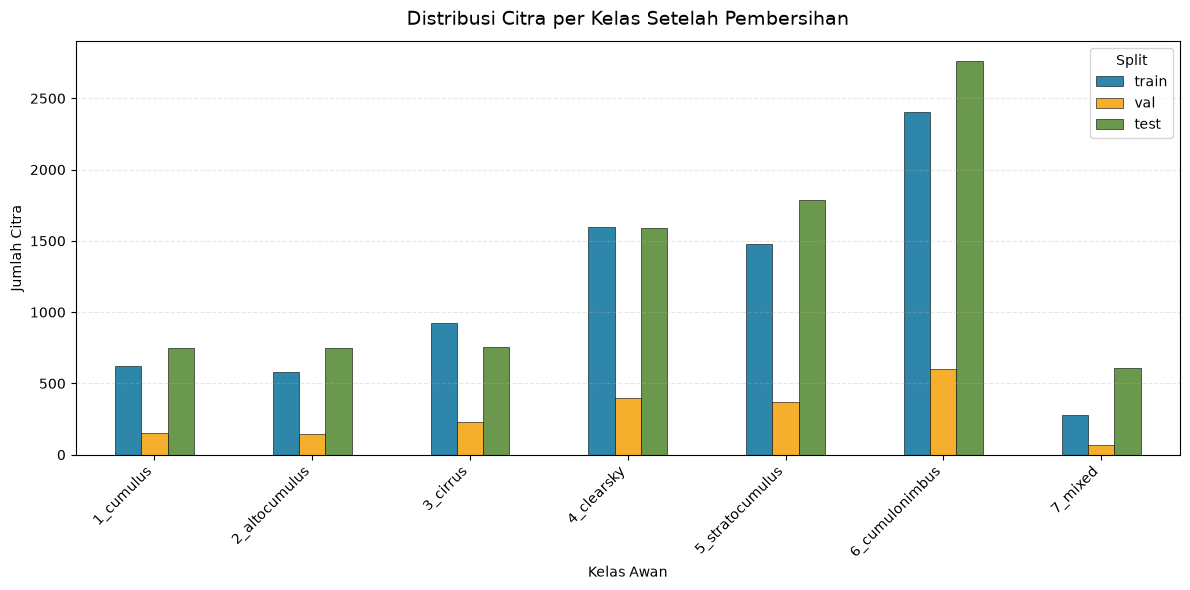

In [59]:
plot_df = distribution_df[
    [
        "train",
        "val",
        "test",
    ]
].copy()

figure_width = max(
    12,
    len(plot_df) * 0.9,
)

axis = plot_df.plot(
    kind="bar",
    figsize=(figure_width, 6),
    color=[
        "#2E86AB",
        "#F6AE2D",
        "#6A994E",
    ],
    edgecolor="black",
    linewidth=0.4,
)

axis.set_title(
    "Distribusi Citra per Kelas "
    "Setelah Pembersihan",
    fontsize=14,
    pad=12,
)

axis.set_xlabel("Kelas Awan")
axis.set_ylabel("Jumlah Citra")

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axis.legend(title="Split")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

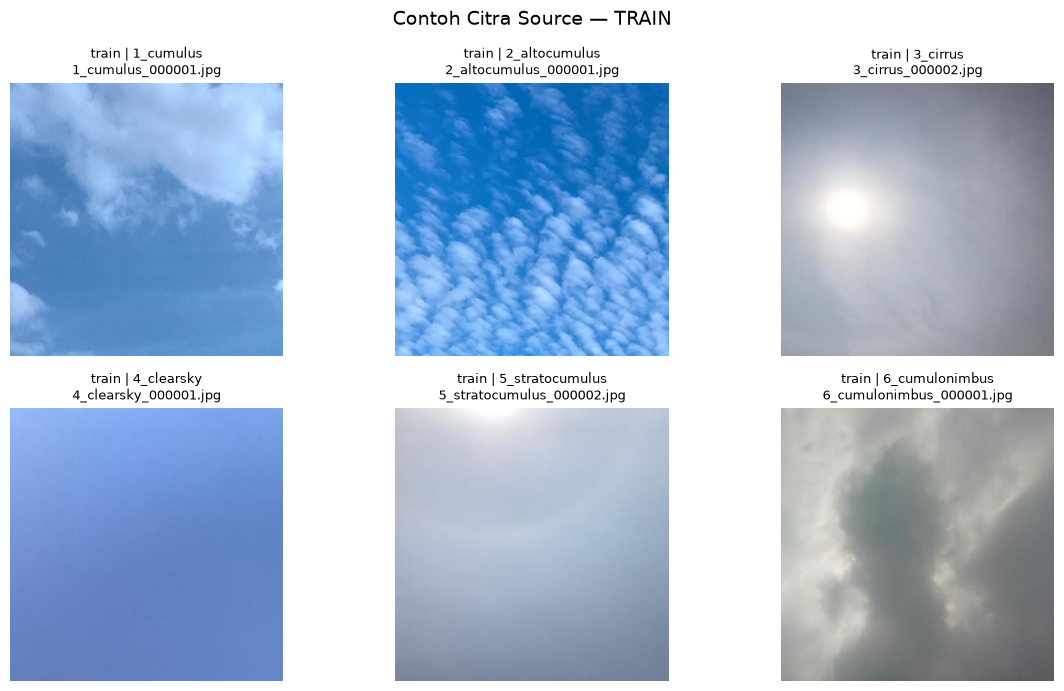

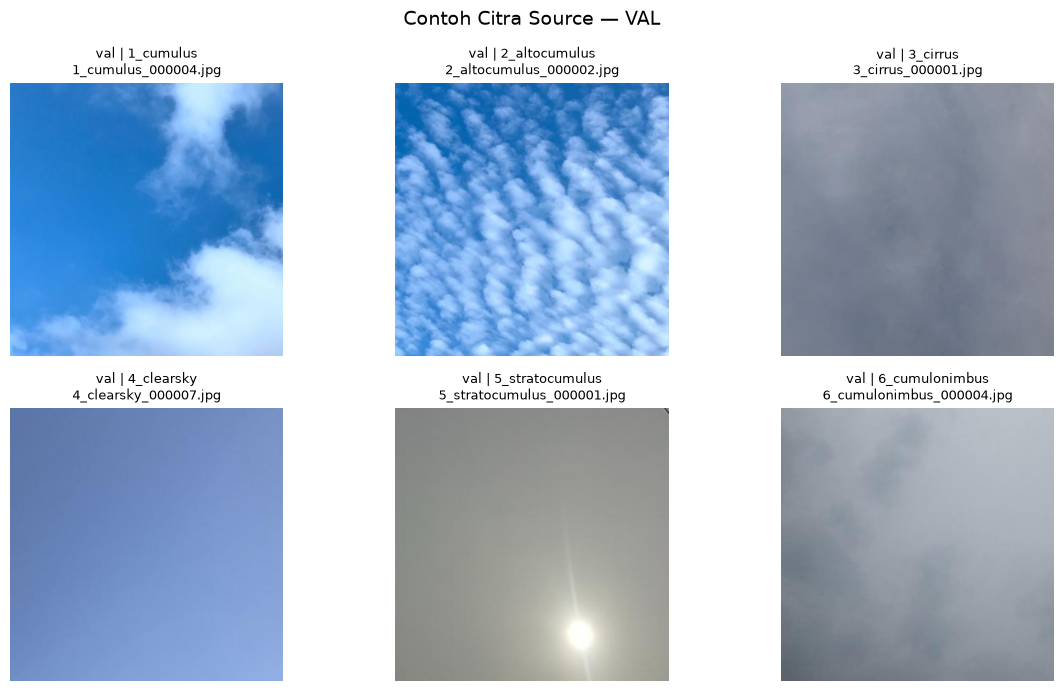

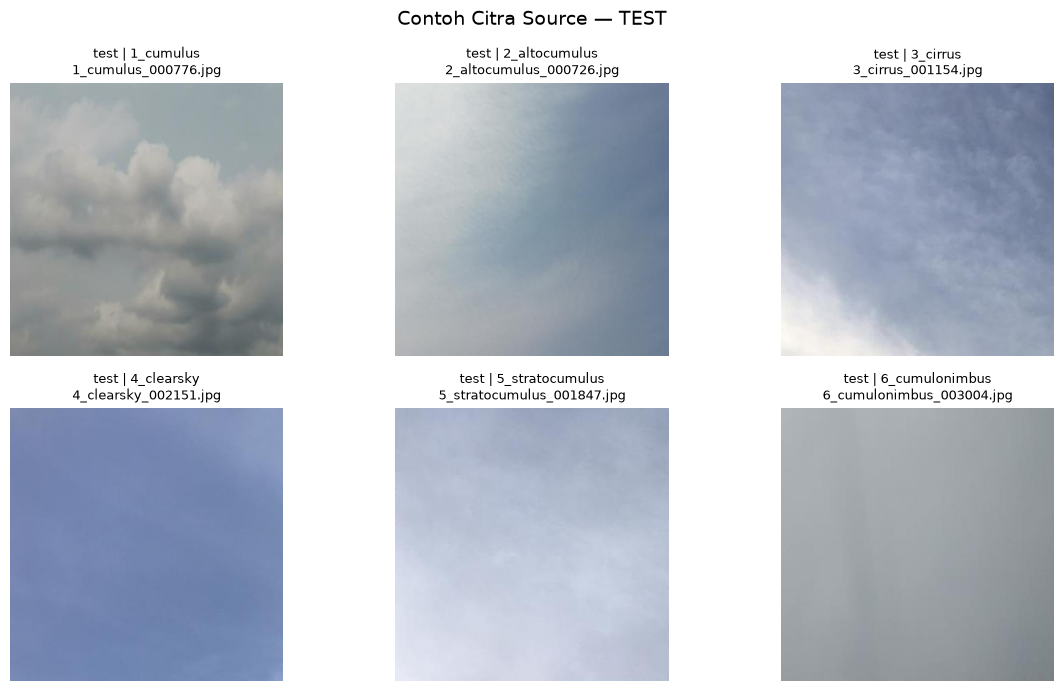

In [60]:
def show_source_samples(
    manifest: pd.DataFrame,
    samples_per_split: int = 6,
) -> None:
    """
    Menampilkan satu contoh citra dari beberapa kelas
    pada setiap split.
    """
    for split_name in [
        "train",
        "val",
        "test",
    ]:
        split_df = manifest[
            manifest["target_split"]
            == split_name
        ].copy()

        if split_df.empty:
            continue

        selected_df = (
            split_df
            .sort_values([
                "class_name",
                "target_relative_path",
            ])
            .groupby(
                "class_name",
                as_index=False,
            )
            .head(1)
            .head(samples_per_split)
        )

        number_of_columns = min(
            3,
            len(selected_df),
        )

        number_of_rows = math.ceil(
            len(selected_df)
            / number_of_columns
        )

        figure, axes = plt.subplots(
            number_of_rows,
            number_of_columns,
            figsize=(
                4 * number_of_columns,
                3.5 * number_of_rows,
            ),
        )

        axes = (
            np.atleast_1d(axes)
            .ravel()
        )

        for axis, row in zip(
            axes,
            selected_df.itertuples(
                index=False
            ),
        ):
            with Image.open(
                row.target_path
            ) as image:
                axis.imshow(
                    image.convert("RGB")
                )

            axis.set_title(
                f"{split_name} | "
                f"{row.class_name}\n"
                f"{row.filename}",
                fontsize=9,
            )

            axis.axis("off")

        for axis in axes[
            len(selected_df):
        ]:
            axis.axis("off")

        figure.suptitle(
            "Contoh Citra Source — "
            f"{split_name.upper()}",
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()


show_source_samples(
    manifest=manifest_df
)

In [61]:
final_checks = pd.DataFrame({
    "Pemeriksaan": [
        "Raw train tersedia",
        "Raw test tersedia",
        "Training source tidak kosong",
        "Validation source tidak kosong",
        "Test source tidak kosong",
        "Semua file target tersedia",
        "Hash source sama dengan raw",
        "Tidak ada duplikat antar-split",
        "Dataset raw tidak berubah",
        "Manifest tersimpan",
        "Audit pembersihan tersimpan",
        "Ringkasan JSON tersimpan",
    ],

    "Lulus": [
        RAW_TRAIN_DIR.is_dir(),
        RAW_TEST_DIR.is_dir(),
        len(source_train_df) > 0,
        len(source_val_df) > 0,
        len(source_test_df) > 0,
        bool(
            verification_df[
                "exists"
            ].all()
        ),
        bool(
            verification_df[
                "hash_match"
            ].all()
        ),
        not any(
            leakage_checks.values()
        ),
        raw_unchanged,
        manifest_path.is_file(),
        cleaning_audit_path.is_file(),
        summary_path.is_file(),
    ],
})

display(final_checks)


if not final_checks["Lulus"].all():
    failed_checks = final_checks[
        ~final_checks["Lulus"]
    ]

    display(failed_checks)

    raise RuntimeError(
        "Tahap pembersihan belum lulus "
        "seluruh pemeriksaan."
    )


print("SEMUA PEMERIKSAAN LULUS")
print(
    "Dataset pada folder source siap "
    "digunakan untuk tahap berikutnya."
)

,Pemeriksaan,Lulus
0,Raw train tersedia,True
1,Raw test tersedia,True
2,Training source tidak kosong,True
3,Validation source tidak kosong,True
4,Test source tidak kosong,True
5,Semua file target tersedia,True
6,Hash source sama dengan raw,True
7,Tidak ada duplikat antar-split,True
8,Dataset raw tidak berubah,True
9,Manifest tersimpan,True


SEMUA PEMERIKSAAN LULUS
Dataset pada folder source siap digunakan untuk tahap berikutnya.


# Kesimpulan

Tahap pembersihan dan persiapan dataset telah selesai.

Dataset training original telah diperiksa berdasarkan keterbacaan file, ukuran citra, struktur kelas, dan SHA-256. Citra yang rusak, identik dengan test, memiliki konflik label, atau merupakan duplikat training telah dikeluarkan dari kandidat training.

Training bersih kemudian dibagi menjadi train dan validation secara stratified. Dataset test hanya berasal dari folder test original dan tidak digunakan dalam pembentukan validation.

Hasil dataset tersedia pada:

dataset/source/
├── train/
├── val/
└── test/

Metadata pembersihan tersedia pada:

dataset/processed/
├── dataset_inventory_raw.csv
├── dataset_cleaning_audit.csv
├── duplicate_report.csv
├── dataset_split_manifest.csv
├── class_distribution_source.csv
└── cleaning_summary.json

Pada tahap ini belum dilakukan resize, normalisasi, augmentasi, atau transformasi piksel. Tahapan tersebut dilakukan setelah dataset source selesai diperiksa.